# prediction_length (train) 1 vs 4 A/B — 실측치 데이터

학습 시 `--prediction-length` 를 4(현행) vs 1 로 두고 비교. 구 folder 2026-08-18 predlen 스윕의 실측치 재현. context_length = 스윕 최적값 (**blaine 512 / residue 256**).

- full fine-tune / 1000 steps / lr 1e-6 / batch 64 / stride 4
- **평가는 두 arm 모두 1-step** (`backtest.py`가 `predict_df` 를 `prediction_length=1` 로   하드코딩 — chronos-2는 학습보다 짧은 horizon 추론 OK). 그래서 "1-step 예측 정확도"라는   잣대가 두 arm에 동일하게 적용됨.
- 같은 canonical CSV, 같은 평가 지점 / naive baseline

**가설**: 타깃(blaine/residue)이 4시간 grid에만 존재 → predlen=1이면 랜덤 학습 윈도우의 다음 1시간이 실측 시각일 확률이 낮아 학습 신호 낭비. predlen≥4면 어떤 4시간 윈도우든 실측 시각 포함. 실측치는 타깃이 더 sparse(82.6% NaN)라 이 효과가 더 클 것.

정규화 skill-score `< 1` = naive 이김. GPU 안 씀.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

ROOT = Path.cwd()
while not (ROOT / 'config.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import config as cfg
from eval.metrics_utils import compute_metrics, macro_average_mae, normalized_skill_score

CTX = {'blaine': 512, 'residue': 256}
ARMS = ['predlen1', 'predlen4']
LABEL = {'predlen1': 'predlen=1', 'predlen4': 'predlen=4 (현행)'}
COLOR = {'predlen1': 'tab:red', 'predlen4': 'tab:green'}


## 1. 결과 로딩

In [2]:
res, missing = {}, []
for t in cfg.TARGET_COLS:
    for arm in ARMS:
        p = ROOT / 'eval' / f'backtest_{t}_ctx{CTX[t]}_{arm}.csv'
        if p.exists():
            res[(t, arm)] = pd.read_csv(p, parse_dates=['timestamp'])
        else:
            missing.append(p.name)
print('missing:', missing or 'NONE', '| loaded:', len(res), '/ 4')


missing: NONE | loaded: 4 / 4


## 2. 요약표

In [3]:
rows = []
for t in cfg.TARGET_COLS:
    for arm in ARMS:
        df = res.get((t, arm))
        if df is None:
            continue
        m = compute_metrics(df, cfg.SPEC_RANGES[t])
        rows.append({'target': t, 'arm': arm, 'ctx': CTX[t], 'n': len(df),
                     'MAE': round(m['MAE'], 4), 'R2': round(m['R2'], 4),
                     'spec%': round(m['spec_accuracy'] * 100, 2),
                     'cov80%': round(m['interval_coverage'] * 100, 2),
                     'macro_MAE': round(macro_average_mae(df), 4),
                     'skill': round(normalized_skill_score(df), 4),
                     'naive_MAE': round(float(np.abs(df['actual'] - df['naive_pred']).mean()), 4)})
summary = pd.DataFrame(rows).set_index(['target', 'arm'])
summary


ctx    n      MAE      R2  spec%  cov80%  macro_MAE   skill  \
target  arm                                                                     
blaine  predlen1  512  851  71.0517  0.4514  69.57   67.22    70.9951  0.8491   
        predlen4  512  851  69.6349  0.4737  70.15   66.16    69.5736  0.8319   
residue predlen1  256  856   0.4782  0.7536  82.59   72.90     0.4778  0.8423   
        predlen4  256  856   0.4585  0.7701  83.06   69.74     0.4581  0.8086   

                  naive_MAE  
target  arm                  
blaine  predlen1    83.7673  
        predlen4    83.7673  
residue predlen1     0.5685  
        predlen4     0.5685

## 3. Δ (predlen4 − predlen1)

음수 = predlen4가 나음 (MAE/skill 기준).

In [4]:
for t in cfg.TARGET_COLS:
    a, b = res[(t, 'predlen1')], res[(t, 'predlen4')]
    ma, mb = compute_metrics(a, cfg.SPEC_RANGES[t]), compute_metrics(b, cfg.SPEC_RANGES[t])
    sa, sb = normalized_skill_score(a), normalized_skill_score(b)
    print(f'{t:8s} (ctx {CTX[t]}):  ΔMAE={mb["MAE"]-ma["MAE"]:+.4f}  ΔR2={mb["R2"]-ma["R2"]:+.4f}  '
          f'Δskill={sb-sa:+.4f}   |  predlen1 skill={sa:.4f}  predlen4 skill={sb:.4f}')


blaine   (ctx 512):  ΔMAE=-1.4168  ΔR2=+0.0222  Δskill=-0.0172   |  predlen1 skill=0.8491  predlen4 skill=0.8319
residue  (ctx 256):  ΔMAE=-0.0196  ΔR2=+0.0165  Δskill=-0.0337   |  predlen1 skill=0.8423  predlen4 skill=0.8086


## 4. 타깃별 비교 그래프

빨강 = predlen1, 초록 = predlen4. MAE 패널 회색 점선 = naive baseline.

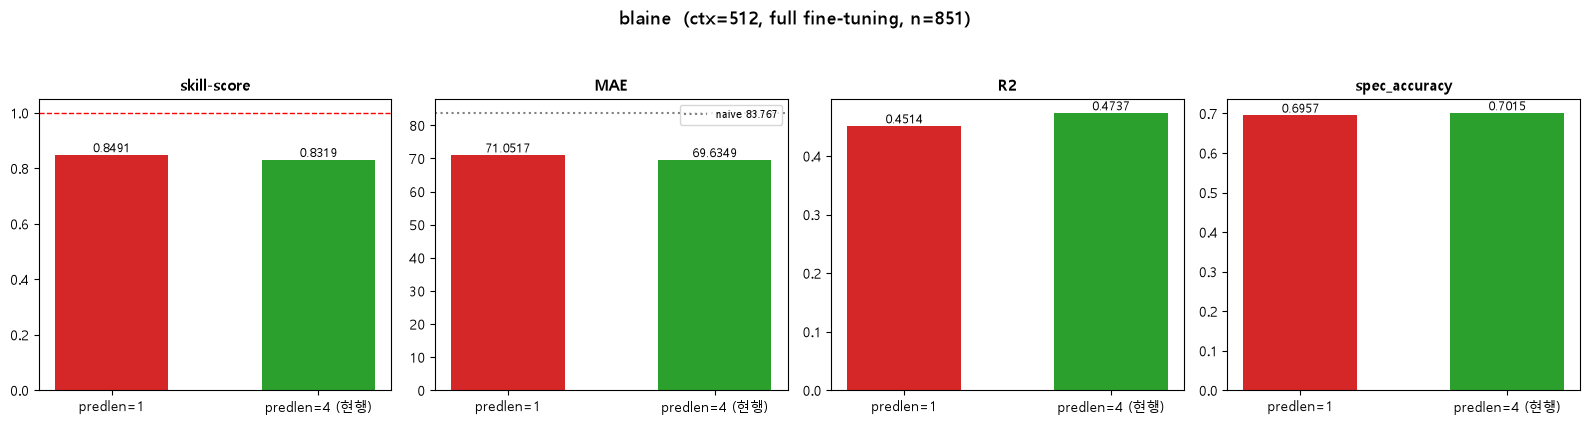

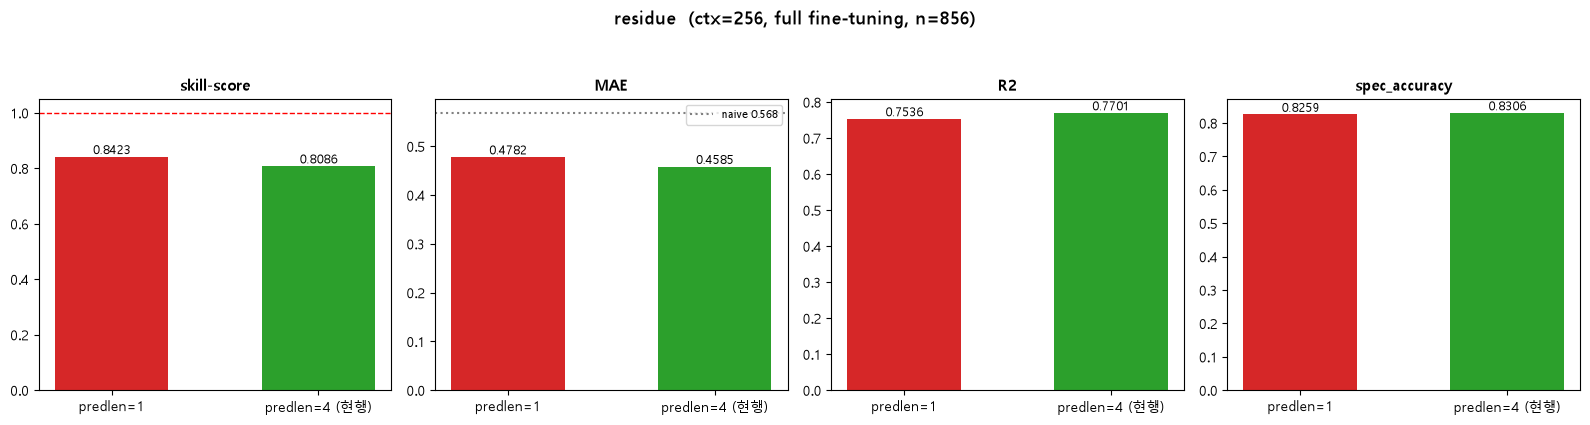

In [5]:
def plot_target(t):
    d = {arm: res[(t, arm)] for arm in ARMS}
    m = {arm: compute_metrics(d[arm], cfg.SPEC_RANGES[t]) for arm in ARMS}
    sk = {arm: normalized_skill_score(d[arm]) for arm in ARMS}
    nmae = float(np.abs(d['predlen4']['actual'] - d['predlen4']['naive_pred']).mean())
    panels = [('skill-score', sk, None), ('MAE', {k: m[k]['MAE'] for k in ARMS}, nmae),
              ('R2', {k: m[k]['R2'] for k in ARMS}, None),
              ('spec_accuracy', {k: m[k]['spec_accuracy'] for k in ARMS}, None)]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'{t}  (ctx={CTX[t]}, full fine-tuning, n={len(d["predlen4"])})',
                 fontsize=13, fontweight='bold', y=1.05)
    for ax, (name, vals, naive) in zip(axes, panels):
        xs = np.arange(len(ARMS))
        bars = ax.bar(xs, [vals[a] for a in ARMS], color=[COLOR[a] for a in ARMS], width=0.55)
        for bb, a in zip(bars, ARMS):
            ax.text(bb.get_x() + bb.get_width() / 2, bb.get_height(), f'{vals[a]:.4f}',
                    ha='center', va='bottom', fontsize=9)
        if naive is not None:
            ax.axhline(naive, color='grey', ls=':', label=f'naive {naive:.3f}'); ax.legend(fontsize=8)
        if name == 'skill-score':
            ax.axhline(1.0, color='red', ls='--', lw=1)
        ax.set_xticks(xs); ax.set_xticklabels([LABEL[a] for a in ARMS])
        ax.set_title(name, fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()

for t in cfg.TARGET_COLS:
    plot_target(t)


## 5. 결론

In [6]:
for t in cfg.TARGET_COLS:
    a, b = res[(t, 'predlen1')], res[(t, 'predlen4')]
    sa, sb = normalized_skill_score(a), normalized_skill_score(b)
    ma = compute_metrics(a, cfg.SPEC_RANGES[t])['MAE']
    mb = compute_metrics(b, cfg.SPEC_RANGES[t])['MAE']
    win = 'predlen=4' if sb < sa else 'predlen=1'
    print(f'{t:8s}: predlen1 skill={sa:.4f} MAE={ma:.4f}  |  predlen4 skill={sb:.4f} MAE={mb:.4f}  -> {win} 우세 '
          f'(Δskill={sb-sa:+.4f})')


blaine  : predlen1 skill=0.8491 MAE=71.0517  |  predlen4 skill=0.8319 MAE=69.6349  -> predlen=4 우세 (Δskill=-0.0172)
residue : predlen1 skill=0.8423 MAE=0.4782  |  predlen4 skill=0.8086 MAE=0.4585  -> predlen=4 우세 (Δskill=-0.0337)


<!-- 결론 텍스트는 EXPERIMENT_LOG.md 참조 -->